In [ ]:
# If needed in Colab: Runtime -> Change runtime type -> GPU

# =========================
# HF token setup
# =========================

# # Option A: paste your token here


# Option B (recommended): use a Colab secret named HF_TOKEN
from google.colab import userdata
HF_TOKEN = userdata.get("HF_TOKEN")

import os
os.environ["HF_TOKEN"] = HF_TOKEN

!rm -rf /content/GTR
!pip -q install datasets pyarrow pandas numpy scikit-learn matplotlib
!git clone https://github.com/macovaseas/GTR.git

%cd /content/GTR
!pip -q install -r requirements.txt
!mkdir -p dataset

Cloning into 'GTR'...
remote: Enumerating objects: 93, done.
remote: Counting objects: 100% (93/93), done.
remote: Compressing objects: 100% (54/54), done.
remote: Total 93 (delta 42), reused 83 (delta 37), pack-reused 0 (from 0)
Receiving objects: 100% (93/93), 4.12 MiB | 15.87 MiB/s, done.
Resolving deltas: 100% (42/42), done.
/content/GTR


In [ ]:
from datasets import load_dataset
import pandas as pd
import os
import time

SYMS = ["AAPL", "JPM", "XOM", "PG", "HD"]

start_time = time.time()
print("Loading only needed rows/columns from Hugging Face...")

ds = load_dataset(
    "paperswithbacktest/Stocks-Daily-Price",
    split="train",
    token=os.environ["HF_TOKEN"],
    columns=["date", "symbol", "adj_close"],
    filters=[("symbol", "in", SYMS)],
    verification_mode="no_checks",
)

print(f"Loaded filtered dataset in {time.time() - start_time:.1f}s")
print("Number of filtered rows:", len(ds))

print("\nConverting to pandas...")
df_long = ds.to_pandas()
print("Filtered long-format shape:", df_long.shape)
print(df_long.head())

df_long["date"] = pd.to_datetime(df_long["date"]).dt.strftime("%Y-%m-%d")

print("\nPivoting to wide format...")
df_wide = (
    df_long
    .pivot_table(index="date", columns="symbol", values="adj_close", aggfunc="last")
    .sort_index()
)

df_wide = df_wide[SYMS]
df_wide = df_wide.dropna().reset_index()
df_wide.columns.name = None

csv_path = "/content/GTR/dataset/stock5_adj_close.csv"

print(f"\nSaving CSV to {csv_path} ...")
df_wide.to_csv(csv_path, index=False)

print("\nSaved successfully.")
print("Wide-format shape:", df_wide.shape)
print(df_wide.head())
print(df_wide.tail())

Loading only needed rows/columns from Hugging Face...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00004.parquet:   0%|          | 0.00/126M [00:00<?, ?B/s]

data/train-00001-of-00004.parquet:   0%|          | 0.00/127M [00:00<?, ?B/s]

data/train-00002-of-00004.parquet:   0%|          | 0.00/126M [00:00<?, ?B/s]

data/train-00003-of-00004.parquet:   0%|          | 0.00/127M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/24891169 [00:00<?, ? examples/s]

Loaded filtered dataset in 15.0s
Number of filtered rows: 66493

Converting to pandas...
Filtered long-format shape: (66493, 3)
  symbol        date  adj_close
0   AAPL  1980-12-12   0.098297
1   AAPL  1980-12-15   0.093169
2   AAPL  1980-12-16   0.086331
3   AAPL  1980-12-17   0.088468
4   AAPL  1980-12-18   0.091032

Pivoting to wide format...

Saving CSV to /content/GTR/dataset/stock5_adj_close.csv ...

Saved successfully.
Wide-format shape: (11203, 6)
         date      AAPL       JPM       XOM        PG        HD
0  1981-09-22  0.057697  1.542048  0.633536  0.666151  0.016743
1  1981-09-23  0.056415  1.542048  0.630981  0.656899  0.016743
2  1981-09-24  0.055987  1.522963  0.620762  0.652273  0.016743
3  1981-09-25  0.048721  1.522963  0.613099  0.643021  0.016743
4  1981-09-28  0.049149  1.500062  0.633536  0.661526  0.016743
             date        AAPL         JPM         XOM          PG          HD
11198  2026-02-27  264.179993  300.299988  152.500000  167.199997  380.720001


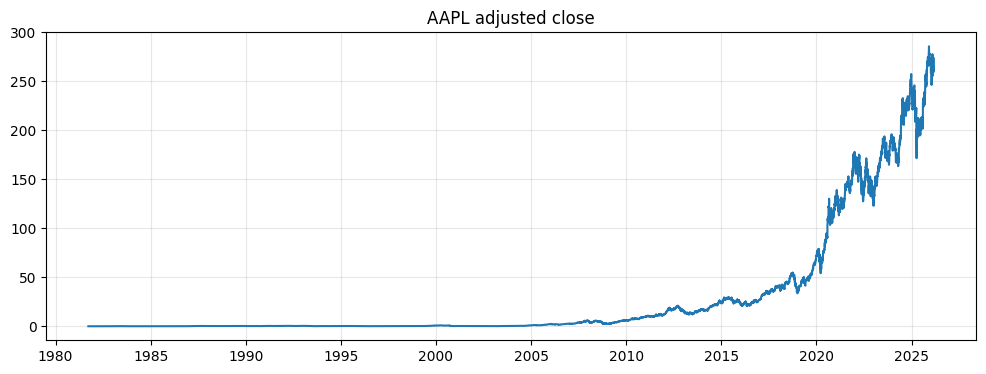

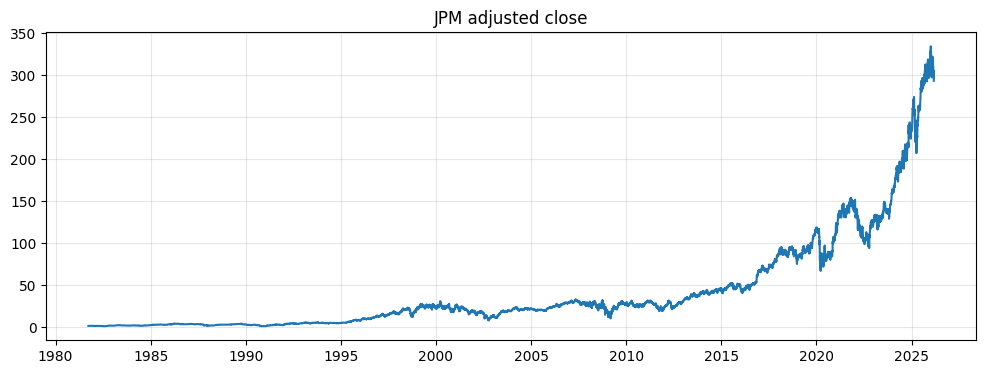

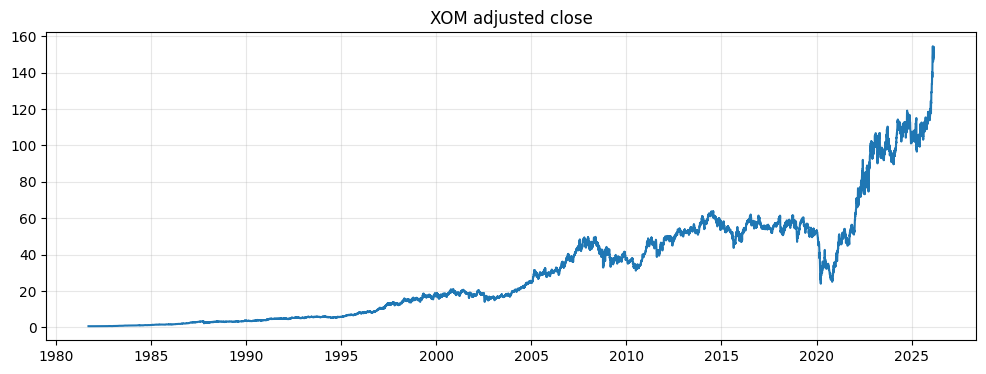

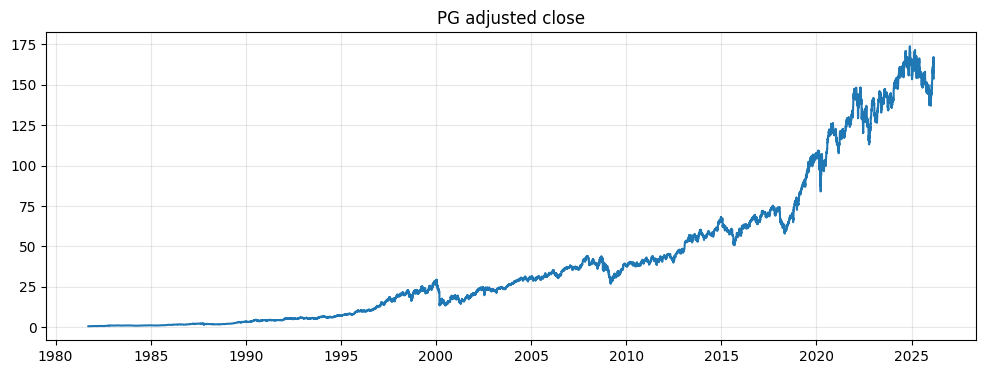

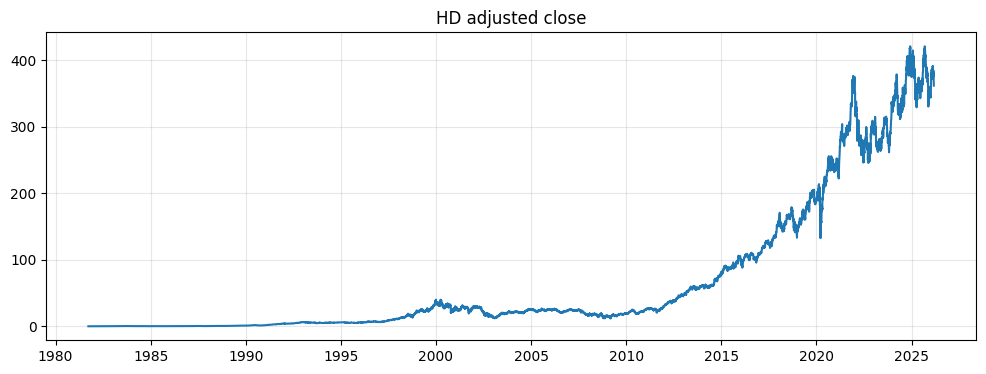

In [ ]:
import matplotlib.pyplot as plt

plot_df = df_wide.copy()
plot_df["date"] = pd.to_datetime(plot_df["date"])
plot_df = plot_df.set_index("date")

for sym in SYMS:
    plt.figure(figsize=(12, 4))
    plt.plot(plot_df.index, plot_df[sym])
    plt.title(f"{sym} adjusted close")
    plt.grid(True, alpha=0.3)
    plt.show()

In [ ]:
file_path = "/content/GTR/utils/tools.py"

with open(file_path, "r") as f:
    text = f.read()

text = text.replace("np.Inf", "np.inf")

with open(file_path, "w") as f:
    f.write(text)

print("Patched utils/tools.py: replaced np.Inf with np.inf")

Patched utils/tools.py: replaced np.Inf with np.inf


In [ ]:
import subprocess
import re
import math
import pandas as pd

def parse_latest_metrics(result_file="/content/GTR/result.txt"):
    with open(result_file, "r") as f:
        text = f.read()

    metric_line = None
    for line in reversed(text.splitlines()):
        if "mse:" in line and "mae:" in line:
            metric_line = line.strip()
            break

    if metric_line is None:
        raise ValueError("Could not find metrics line in result.txt")

    def extract(pattern):
        m = re.search(pattern, metric_line)
        return float(m.group(1)) if m else None

    mse = extract(r"mse:\s*([0-9eE\.\-+]+)")
    mae = extract(r"mae:\s*([0-9eE\.\-+]+)")
    rmse = math.sqrt(mse) if mse is not None else None

    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "raw_metric_line": metric_line,
    }


def run_one_model(
    model_name,
    model_id,
    seq_len=96,
    pred_len=20,
    cycle=5,
    enc_in=5,
    d_model=128,
    batch_size=32,
    lr=1e-3,
    epochs=30,
    seed=2026,
    extra_args=None,
):
    if extra_args is None:
        extra_args = []

    cmd = [
        "python", "-u", "run.py",
        "--is_training", "1",
        "--root_path", "./dataset/",
        "--data_path", "stock5_adj_close.csv",
        "--model_id", model_id,
        "--model", model_name,
        "--data", "custom",
        "--features", "M",
        "--target", "HD",
        "--freq", "b",
        "--seq_len", str(seq_len),
        "--pred_len", str(pred_len),
        "--enc_in", str(enc_in),
        "--dec_in", str(enc_in),
        "--c_out", str(enc_in),
        "--d_model", str(d_model),
        "--dropout", "0.1",
        "--train_epochs", str(epochs),
        "--patience", "5",
        "--batch_size", str(batch_size),
        "--learning_rate", str(lr),
        "--num_workers", "0",
        "--itr", "1",
        "--random_seed", str(seed),
    ]

    if model_name.upper() == "GTR":
        cmd.extend(["--cycle", str(cycle)])

    cmd.extend(extra_args)

    print("\n==================================================")
    print(f"Running model: {model_name}")
    print(" ".join(cmd))
    print("==================================================\n")

    result = subprocess.run(
        cmd,
        text=True,
        capture_output=True
    )

    print("===== STDOUT =====")
    print(result.stdout[-5000:])

    print("\n===== STDERR =====")
    print(result.stderr[-5000:])

    if result.returncode != 0:
        raise RuntimeError(f"{model_name} failed with return code {result.returncode}")

    metrics = parse_latest_metrics("/content/GTR/result.txt")
    metrics["Model"] = model_name
    metrics["Model ID"] = model_id
    return metrics

In [ ]:
BASELINE_MODEL = "DLinear"
GTR_MODEL = "GTR"

SEQ_LEN = 96
PRED_LEN = 20
CYCLE = 5
SEED = 2026

results = []

baseline_metrics = run_one_model(
    model_name=BASELINE_MODEL,
    model_id=f"stock5_baseline_{SEQ_LEN}_{PRED_LEN}",
    seq_len=SEQ_LEN,
    pred_len=PRED_LEN,
    cycle=CYCLE,
    seed=SEED,
)
results.append(baseline_metrics)

gtr_metrics = run_one_model(
    model_name=GTR_MODEL,
    model_id=f"stock5_gtr_{SEQ_LEN}_{PRED_LEN}",
    seq_len=SEQ_LEN,
    pred_len=PRED_LEN,
    cycle=CYCLE,
    seed=SEED,
)
results.append(gtr_metrics)

comparison_df = pd.DataFrame(results)[["Model", "MAE", "MSE", "RMSE", "Model ID"]]

for col in ["MAE", "MSE", "RMSE"]:
    comparison_df[col] = comparison_df[col].map(lambda x: round(x, 6) if x is not None else None)

comparison_df


Running model: DLinear
python -u run.py --is_training 1 --root_path ./dataset/ --data_path stock5_adj_close.csv --model_id stock5_baseline_96_20 --model DLinear --data custom --features M --target HD --freq b --seq_len 96 --pred_len 20 --enc_in 5 --dec_in 5 --c_out 5 --d_model 128 --dropout 0.1 --train_epochs 30 --patience 5 --batch_size 32 --learning_rate 0.001 --num_workers 0 --itr 1 --random_seed 2026

===== STDOUT =====
 241 | Train Loss: 0.0075332 Vali Loss: 0.0484380 Test Loss: 1.5540737
EarlyStopping counter: 2 out of 5
Updating learning rate to 3.518437208883203e-05
	iters: 100, epoch: 19 | loss: 0.0064624
	speed: 0.0056s/iter; left time: 15.5461s
	iters: 200, epoch: 19 | loss: 0.0112489
	speed: 0.0026s/iter; left time: 7.0062s
Epoch: 19 cost time: 0.6331584453582764
Epoch: 19, Steps: 241 | Train Loss: 0.0075265 Vali Loss: 0.0478774 Test Loss: 1.5404559
Validation loss decreased (0.048176 --> 0.047877).  Saving model ...
Updating learning rate to 2.8147497671065623e-05
	iters:

,Model,MAE,MSE,RMSE,Model ID
0,DLinear,0.684907,1.510828,1.229158,stock5_baseline_96_20
1,GTR,0.663424,1.475879,1.214858,stock5_gtr_96_20


In [ ]:
df = comparison_df.copy()
display(df)

if len(df) == 2:
    base = df.iloc[0]
    gtr = df.iloc[1]

    improvement = pd.DataFrame([{
        "Comparison": f"{gtr['Model']} vs {base['Model']}",
        "MAE change %": round(100 * (gtr["MAE"] - base["MAE"]) / base["MAE"], 2) if base["MAE"] else None,
        "MSE change %": round(100 * (gtr["MSE"] - base["MSE"]) / base["MSE"], 2) if base["MSE"] else None,
        "RMSE change %": round(100 * (gtr["RMSE"] - base["RMSE"]) / base["RMSE"], 2) if base["RMSE"] else None,
    }])

    print("\n")
    display(improvement)

,Model,MAE,MSE,RMSE,Model ID
0,DLinear,0.684907,1.510828,1.229158,stock5_baseline_96_20
1,GTR,0.663424,1.475879,1.214858,stock5_gtr_96_20


,Comparison,MAE change %,MSE change %,RMSE change %
0,GTR vs DLinear,-3.14,-2.31,-1.16


# 500 Stocks

In [ ]:
from datasets import load_dataset
import pandas as pd
import os
import numpy as np
import math
import time

tickers = [
"AOMR","REGCP","WRBY","FVRR","NET","AVO","PROF","AQB","PMTS","ESQ","LFT","DUOL","EDBL","HLLY","DINO","VRTL","LIVN","KMPB","HL","LXP",
"STG","OPK","BR","PHAT","SERA","RWAYL","NLY","TELO","CAKE","ABUS","DKNG","DLX","RXST","PRGS","BDTX","CBOE","WLDN","YOU","LANDM","GME",
"EGO","OCCIN","SVRN","FAT","MSFT","UYSCU","SABS","GALT","CDIO","ROIV","DEFT","USB","ELS","SDOT","RDHL","FLYE","BLIV","NWL","ECCW","CNDT",
"ECCV","RKT","CAN","TRUP","ABXL","JBLU","FLGT","USIO","HAL","PCSC","CRK","ALNY","FUFU","SHMD","ULY","AGYS","JBSS","CTVA","NNN","LPRO",
"RBNE","BIPJ","CSTM","ARW","LPBBU","BDL","SWKS","LZMH","M","JFIN","CTRI","JOYY","TGNA","PCVX","ULTA","WINA","TMP","OOMA","ALUR","ATEN",
"MEGI","OAKU","OTEX","EZRA","GETY","TCBC","HGV","HVIIU","DUETU","GNS","PCLA","YEXT","MHUA","FSK","NRDS","NIC","BBD","ALB","BL","ETHZ",
"CALY","UK","AXS","FARM","NVS","TRNS","MRKR","ELA","BOF","IMNN","TCBIO","BXP","GLBZ","TFSL","CYCN","ITP","BRW","USCB","ING","HTT",
"PMTV","RYAM","EEX","DXYZ","CATO","PBI","XPL","GLBS","ADP","PNFPP","SOUN","IIIV","AX","PSIG","ANF","SMID","CTRM","CWH","AFGC","CNC",
"TAP","CRBG","FICO","SRAX","MRNO","TBN","PLRZ","INLX","CVX","DBVT","UI","MGNI","NEXM","VHAI","COHN","VZ","FISI","DCOM","IART","TFPM",
"LCNB","MVBF","VIVK","ENPH","NRIX","BV","BANF","UFCS","EXLS","SSBI","UCB","ASTE","OXLCI","SLNG","RR","SKWD","AMPX","ITIC","PFBC","RL",
"JZXN","AMBR","DLNG","WTW","BOW","IPDN","KRYS","E","FTEK","WIMI","KLTO","VFS","SAY","PALI","AUPH","BMEZ","APEI","SPIR","EGAN","EPWK",
"CLB","UMBF","CIX","CBRE","ATEX","BEAT","BETR","INDI","NUE","HOUS","IMOS","AMZN","WPC","IMNM","ARCO","TCBK","HGLB","DVN","ARMN","CRUS",
"BCAX","BPYPM","XGN","PHR","CBAT","TOL","EQIX","VRA","SSB","XBIO","BNAI","ADCT","HBANL","LB","XIFR","BELFB","HNI","CCRN","CHCO","NE",
"MRUS","CHR","CAPR","SDHC","PRAA","HYLN","RWAYZ","AN","ELME","KRG","PRDO","INKT","TGB","CAE","EFOI","ALFUU","MXCT","ELUT","CMG","THRM",
"GPI","DFSC","OS","CNX","UFG","AA","CF","PGYWW","SONY","MVO","TPG","SKYH","CMSA","TRV","GIFT","RNA","LFMDP","CODX","ARQT","AME","XTIA",
"CPHC","SPFI","ERIE","LNSR","BOSC","PNFP","SOHON","AIFF","RLYB","APAM","IDT","PENG","CVV","LSAK","LIN","CPS","BKD","VYLD","TPGXL","SID",
"TOVX","DDS","HCKT","LBTYK","VLTO","APLT","CGON","DCOMP","USAC","SNDA","KXIN","TRDA","DGLY","MGIH","TACT","SEAT","LSPD","GEF-B","FUND",
"ALEX","ASPN","RAVE","WT","FHB","ESBA","IOTR","HIW","SIBN","MWA","MCRB","OPAD","SIGIP","BKNG","FTAIM","AVX","MITN","DGNX","AQN","BSAC",
"SAGT","GAINZ","TNDM","ONBPO","MCY","ATII","ARL","APVO","GDHG","API","REVB","ISPC","UUU","MBC","AFCG","MP","R","AMOD","VG","HFWA","PRA",
"DK","AGI","DYCQU","CRS","DHCNI","COLB","BVFL","ENLT","JWEL","ANL","PRE","PEW","IRDM","PNRG","AIRI","HG","GWRE","UGRO","INBKZ","DKS",
"DFH","SNFCA","PHGE","GOODO","SNOW","FUTU","RMBS","CRT","BIP","EVEX","TGTX","WILC","CMCM","RHI","RNXT","XYL","SPCB","PDSB","OPAL","RGA",
"NFBK","CNO","KULR","CNA","HTFC","BGS","SOPA","DDT","SIMAU","OMER","CHMG","FCPT","CBIO","LOKVU","INEO","QETAU","LOAR","BDX","NWFL","CMMB",
"ROCK","OMEX","ICHR","FFIV","QFIN","NHPBP","BF-A","NL","DOX","XPER","NTB","NEGG","MPAA","SMMT","EMPD","VTSI","SAIL","SGD","CNR","GRDX",
"NCMI","HY","SPMC","OVV","VRME","FSTR","MGNX","PUK","UA","BIDU","RSSS","NBR","NFGC","NEXA","EVR","ZBRA","TFX","ARI","FIZZ","FBP","PLRX",
"IXHL","SLVM","NMG","ESE","ETH","TNMG","UNFI","LQDA","RCKY","CVCO","AKA","TMUS","QSR","SSII","JHG","WSBF","GVH","PFIS"
]

# -----------------------
# Controls
# -----------------------
VALUE_COL = "adj_close"     # you can switch to "close" if you prefer
MIN_POINTS_PER_TICKER = 800 # only keep tickers with at least this many rows
BATCH_SIZE = 20             # how many tickers per training run (20 is a good starting point)
MAX_TICKERS = None          # or set e.g. 200 if you want to cap runtime

# -----------------------
# Load only the needed columns + filter tickers
# -----------------------
t0 = time.time()
print("Loading filtered rows from HF...")

ds = load_dataset(
    "paperswithbacktest/Stocks-Daily-Price",
    split="train",
    token=os.environ["HF_TOKEN"],
    columns=["date", "symbol", VALUE_COL],
    filters=[("symbol", "in", tickers)],
    verification_mode="no_checks",
)

print(f"Loaded HF subset in {time.time()-t0:.1f}s. Rows: {len(ds):,}")

df_long = ds.to_pandas()
df_long = df_long.rename(columns={VALUE_COL: "y"})
df_long["date"] = pd.to_datetime(df_long["date"]).dt.strftime("%Y-%m-%d")

print("Long df shape:", df_long.shape)

# -----------------------
# Keep tickers with enough data
# -----------------------
counts = df_long["symbol"].value_counts()
good = counts[counts >= MIN_POINTS_PER_TICKER].index.tolist()

if MAX_TICKERS is not None:
    good = good[:MAX_TICKERS]

print(f"Tickers requested: {len(tickers)}")
print(f"Tickers kept (>= {MIN_POINTS_PER_TICKER} points): {len(good)}")

df_long = df_long[df_long["symbol"].isin(good)].copy()

# -----------------------
# Pivot to wide
# -----------------------
print("Pivoting to wide...")
df_wide = (
    df_long.pivot_table(index="date", columns="symbol", values="y", aggfunc="last")
    .sort_index()
)

# Important: with many tickers, dropping rows where ANY ticker is missing can destroy history.
# Strategy: for each batch, we will dropna() only on the batch columns later.

print("Wide shape (dates x tickers):", df_wide.shape)

# -----------------------
# Create batches of tickers
# -----------------------
tickers_kept = list(df_wide.columns)
tickers_batches = [tickers_kept[i:i+BATCH_SIZE] for i in range(0, len(tickers_kept), BATCH_SIZE)]

print(f"Number of batches: {len(tickers_batches)} (batch size = {BATCH_SIZE})")
print("Example batch:", tickers_batches[0][:10], "...")

Loading filtered rows from HF...


Generating train split:   0%|          | 0/24891169 [00:00<?, ? examples/s]

Loaded HF subset in 2.8s. Rows: 2,112,661
Long df shape: (2112661, 3)
Tickers requested: 500
Tickers kept (>= 800 points): 433
Pivoting to wide...
Wide shape (dates x tickers): (16152, 433)
Number of batches: 22 (batch size = 20)
Example batch: ['AA', 'ABUS', 'ADCT', 'ADP', 'AFCG', 'AFGC', 'AGI', 'AGYS', 'AIFF', 'AIRI'] ...


In [ ]:
import os

out_dir = "/content/GTR/dataset/batches"
os.makedirs(out_dir, exist_ok=True)

batch_csvs = []

for bi, batch in enumerate(tickers_batches):
    # For this batch only: keep date + these columns, then drop rows missing within the batch
    batch_df = df_wide[batch].dropna().copy()
    batch_df = batch_df.reset_index()  # index -> date col

    # Skip batches that are too short for your seq_len/pred_len
    if len(batch_df) < 300:  # just a safety; adjust if needed
        print(f"Skipping batch {bi} (too short after dropna): len={len(batch_df)}")
        continue

    csv_path = os.path.join(out_dir, f"stock_batch_{bi:03d}.csv")
    batch_df.to_csv(csv_path, index=False)
    batch_csvs.append((bi, csv_path, batch, len(batch_df)))

print("Prepared batch CSVs:", len(batch_csvs))
print("First CSV:", batch_csvs[0][1])

Prepared batch CSVs: 22
First CSV: /content/GTR/dataset/batches/stock_batch_000.csv


In [ ]:
import subprocess
import pandas as pd
import numpy as np
import torch
from sklearn.preprocessing import StandardScaler
from types import SimpleNamespace
from pandas.tseries.offsets import BDay
from models.GTR import Model as GTRModel
import os

# -----------------------
# Model / forecast params
# -----------------------
SEQ_LEN = 96
PRED_LEN = 20
CYCLE = 5
D_MODEL = 128
EPOCHS = 10         # start small, increase later
BATCH_SIZE_TRAIN = 32
LR = 1e-3
SEED = 2026

forecast_out_dir = "/content/GTR/forecasts"
os.makedirs(forecast_out_dir, exist_ok=True)

def train_gtr_on_csv(csv_path, enc_in, model_id, target_name):
    cmd = [
        "python", "-u", "run.py",
        "--is_training", "1",
        "--root_path", os.path.dirname(csv_path) + "/",
        "--data_path", os.path.basename(csv_path),
        "--model_id", model_id,
        "--model", "GTR",
        "--data", "custom",
        "--features", "M",
        "--target", target_name,   # MUST exist in CSV columns
        "--freq", "b",
        "--seq_len", str(SEQ_LEN),
        "--pred_len", str(PRED_LEN),
        "--enc_in", str(enc_in),
        "--dec_in", str(enc_in),
        "--c_out", str(enc_in),
        "--cycle", str(CYCLE),
        "--d_model", str(D_MODEL),
        "--dropout", "0.1",
        "--train_epochs", str(EPOCHS),
        "--patience", "5",
        "--batch_size", str(BATCH_SIZE_TRAIN),
        "--learning_rate", str(LR),
        "--num_workers", "0",
        "--itr", "1",
        "--random_seed", str(SEED),
    ]
    r = subprocess.run(cmd, text=True, capture_output=True)
    if r.returncode != 0:
        print("STDOUT tail:\n", r.stdout[-2000:])
        print("STDERR tail:\n", r.stderr[-2000:])
        raise RuntimeError(f"GTR training failed for {csv_path}")
    return r.stdout


def load_checkpoint_and_forecast(csv_path, tickers_batch, setting):
    ckpt = f"/content/GTR/checkpoints/{setting}/checkpoint.pth"
    if not os.path.exists(ckpt):
        raise FileNotFoundError(f"Checkpoint not found: {ckpt}")

    df = pd.read_csv(csv_path)
    df["date"] = pd.to_datetime(df["date"])

    X = df[tickers_batch].values.astype(np.float32)

    # Same split logic as repo (train = 70%)
    n = len(df)
    n_train = int(n * 0.7)

    scaler = StandardScaler()
    scaler.fit(X[:n_train])
    Xs = scaler.transform(X)

    if len(Xs) < SEQ_LEN:
        raise ValueError(f"Not enough rows ({len(Xs)}) for SEQ_LEN={SEQ_LEN} in {csv_path}")

    x_last = Xs[-SEQ_LEN:]
    x_last = torch.tensor(x_last, dtype=torch.float32).unsqueeze(0)  # (1, seq_len, C)

    cycle_index = torch.tensor([len(Xs) % CYCLE], dtype=torch.int64)

    configs = SimpleNamespace(
        seq_len=SEQ_LEN,
        pred_len=PRED_LEN,
        enc_in=len(tickers_batch),
        cycle=CYCLE,
        d_model=D_MODEL,
        dropout=0.1,
        use_revin=1,
        individual=0,
    )

    model = GTRModel(configs)
    state = torch.load(ckpt, map_location="cpu")
    model.load_state_dict(state)
    model.eval()

    with torch.no_grad():
        pred_scaled = model(x_last, cycle_index).squeeze(0).cpu().numpy()

    pred = scaler.inverse_transform(pred_scaled)

    future_dates = pd.bdate_range(df["date"].iloc[-1] + BDay(1), periods=PRED_LEN)
    forecast_df = pd.DataFrame(pred, columns=tickers_batch, index=future_dates)
    return forecast_df


=== Batch 0 | tickers=20 | rows=870 ===
Saved forecast: /content/GTR/forecasts/forecast_batch_000.csv

=== Batch 1 | tickers=20 | rows=1160 ===
Saved forecast: /content/GTR/forecasts/forecast_batch_001.csv

=== Batch 2 | tickers=20 | rows=1081 ===
Saved forecast: /content/GTR/forecasts/forecast_batch_002.csv

=== Batch 3 | tickers=20 | rows=1157 ===
Saved forecast: /content/GTR/forecasts/forecast_batch_003.csv

=== Batch 4 | tickers=20 | rows=997 ===
Saved forecast: /content/GTR/forecasts/forecast_batch_004.csv

=== Batch 5 | tickers=20 | rows=869 ===
Saved forecast: /content/GTR/forecasts/forecast_batch_005.csv

=== Batch 6 | tickers=20 | rows=937 ===
Saved forecast: /content/GTR/forecasts/forecast_batch_006.csv

=== Batch 7 | tickers=20 | rows=951 ===
Saved forecast: /content/GTR/forecasts/forecast_batch_007.csv

=== Batch 8 | tickers=20 | rows=1039 ===
Saved forecast: /content/GTR/forecasts/forecast_batch_008.csv

=== Batch 9 | tickers=20 | rows=875 ===
Saved forecast: /content/GTR

In [ ]:
import re
import math
import pandas as pd
from IPython.display import display

RESULT_TXT = "/content/GTR/result.txt"

def parse_last_metrics_line(result_file=RESULT_TXT):
    """
    Finds the most recent metrics line in result.txt and returns a dict.
    The repo's metrics include: mae, mse, rmse, mape, mspe, rse, corr.
    """
    with open(result_file, "r") as f:
        lines = f.read().splitlines()

    # Find the last line that contains mse & mae (repo always prints these)
    metric_line = None
    for line in reversed(lines):
        if ("mse:" in line) and ("mae:" in line):
            metric_line = line.strip()
            break

    if metric_line is None:
        raise ValueError("Could not find a metrics line in result.txt")

    def grab(key):
        m = re.search(rf"{key}:\s*([0-9eE\.\-+]+)", metric_line)
        return float(m.group(1)) if m else None

    mse  = grab("mse")
    mae  = grab("mae")
    rmse = math.sqrt(mse) if mse is not None else None

    out = {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "MAPE": grab("mape"),
        "MSPE": grab("mspe"),
        "RSE": grab("rse"),
        "CORR": grab("corr"),
        "raw_metric_line": metric_line,
    }
    return out


# -----------------------
# Example: integrate into your batch loop
# -----------------------
metrics_rows = []

for bi, csv_path, batch, nrows in batch_csvs:
    print(f"\n=== Batch {bi} | tickers={len(batch)} | rows={nrows} ===")
    enc_in = len(batch)
    model_id = f"stocks_batch_{bi:03d}_sl{SEQ_LEN}_pl{PRED_LEN}"
    target_name = batch[0]

    # Train
    train_gtr_on_csv(csv_path, enc_in=enc_in, model_id=model_id, target_name=target_name)

    # Parse metrics right after training/testing finishes
    m = parse_last_metrics_line()
    m.update({
        "batch": bi,
        "model": "GTR",
        "model_id": model_id,
        "seq_len": SEQ_LEN,
        "pred_len": PRED_LEN,
        "cycle": CYCLE,
        "n_tickers": len(batch),
        "n_rows": nrows,
        "target": target_name,
        "tickers": ",".join(batch),
        "csv_path": csv_path,
    })
    metrics_rows.append(m)

    # Forecast (optional; keep if you want)
    setting = f"{model_id}_GTR_custom_ftM_sl{SEQ_LEN}_pl{PRED_LEN}_cycle{CYCLE}_seed{SEED}"
    forecast_df = load_checkpoint_and_forecast(csv_path, batch, setting)
    out_path = os.path.join(forecast_out_dir, f"forecast_batch_{bi:03d}.csv")
    forecast_df.to_csv(out_path)
    print("Saved forecast:", out_path)

# Build metrics table
metrics_df = pd.DataFrame(metrics_rows)

# Nice ordering + rounding
cols_first = ["batch","model","model_id","seq_len","pred_len","cycle","n_tickers","n_rows","MAE","MSE","RMSE","MAPE","MSPE","RSE","CORR","target"]
cols_rest = [c for c in metrics_df.columns if c not in cols_first]
metrics_df = metrics_df[cols_first + cols_rest]

for c in ["MAE","MSE","RMSE","MAPE","MSPE","RSE","CORR"]:
    if c in metrics_df.columns:
        metrics_df[c] = metrics_df[c].map(lambda x: round(x, 6) if pd.notnull(x) else x)

display(metrics_df)

out_csv = "/content/GTR/metrics_all_batches.csv"
metrics_df.to_csv(out_csv, index=False)
print("Saved metrics to:", out_csv)


=== Batch 0 | tickers=20 | rows=870 ===
Saved forecast: /content/GTR/forecasts/forecast_batch_000.csv

=== Batch 1 | tickers=20 | rows=1160 ===
Saved forecast: /content/GTR/forecasts/forecast_batch_001.csv

=== Batch 2 | tickers=20 | rows=1081 ===
Saved forecast: /content/GTR/forecasts/forecast_batch_002.csv

=== Batch 3 | tickers=20 | rows=1157 ===
Saved forecast: /content/GTR/forecasts/forecast_batch_003.csv

=== Batch 4 | tickers=20 | rows=997 ===
Saved forecast: /content/GTR/forecasts/forecast_batch_004.csv

=== Batch 5 | tickers=20 | rows=869 ===
Saved forecast: /content/GTR/forecasts/forecast_batch_005.csv

=== Batch 6 | tickers=20 | rows=937 ===
Saved forecast: /content/GTR/forecasts/forecast_batch_006.csv

=== Batch 7 | tickers=20 | rows=951 ===
Saved forecast: /content/GTR/forecasts/forecast_batch_007.csv

=== Batch 8 | tickers=20 | rows=1039 ===
Saved forecast: /content/GTR/forecasts/forecast_batch_008.csv

=== Batch 9 | tickers=20 | rows=875 ===
Saved forecast: /content/GTR

,batch,model,model_id,seq_len,pred_len,cycle,n_tickers,n_rows,MAE,MSE,RMSE,MAPE,MSPE,RSE,CORR,target,raw_metric_line,tickers,csv_path
0,0,GTR,stocks_batch_000_sl96_pl20,96,20,5,20,870,0.359017,0.371638,0.609621,None,None,None,None,AA,"mse:0.3716379702091217, mae:0.3590174913406372","AA,ABUS,ADCT,ADP,AFCG,AFGC,AGI,AGYS,AIFF,AIRI,...",/content/GTR/dataset/batches/stock_batch_000.csv
1,1,GTR,stocks_batch_001_sl96_pl20,96,20,5,20,1160,0.286027,0.349921,0.591541,None,None,None,None,AN,"mse:0.3499211072921753, mae:0.28602680563926697","AN,ANF,AOMR,APAM,APEI,API,APLT,APVO,AQB,AQN,AR...",/content/GTR/dataset/batches/stock_batch_001.csv
2,2,GTR,stocks_batch_002_sl96_pl20,96,20,5,20,1081,0.347874,0.312376,0.558906,None,None,None,None,AUPH,"mse:0.31237563490867615, mae:0.34787434339523315","AUPH,AVO,AVX,AX,AXS,BANF,BBD,BDL,BDTX,BDX,BEAT...",/content/GTR/dataset/batches/stock_batch_002.csv
3,3,GTR,stocks_batch_003_sl96_pl20,96,20,5,20,1157,0.360771,0.696096,0.834324,None,None,None,None,BMEZ,"mse:0.6960962414741516, mae:0.3607714772224426","BMEZ,BNAI,BOSC,BPYPM,BR,BRW,BSAC,BV,BVFL,BXP,C...",/content/GTR/dataset/batches/stock_batch_003.csv
4,4,GTR,stocks_batch_004_sl96_pl20,96,20,5,20,997,0.298664,0.243619,0.493577,None,None,None,None,CCRN,"mse:0.24361862242221832, mae:0.2986644208431244","CCRN,CDIO,CF,CHCO,CHMG,CHR,CIX,CLB,CMCM,CMG,CM...",/content/GTR/dataset/batches/stock_batch_004.csv
5,5,GTR,stocks_batch_005_sl96_pl20,96,20,5,20,869,0.459415,0.709152,0.842112,None,None,None,None,COLB,"mse:0.7091522812843323, mae:0.4594152271747589","COLB,CPHC,CPS,CRBG,CRK,CRS,CRT,CRUS,CSTM,CTRM,...",/content/GTR/dataset/batches/stock_batch_005.csv
6,6,GTR,stocks_batch_006_sl96_pl20,96,20,5,20,937,0.298849,0.283529,0.532474,None,None,None,None,DDT,"mse:0.28352880477905273, mae:0.2988487482070923","DDT,DFH,DFSC,DGLY,DHCNI,DINO,DK,DKNG,DKS,DLNG,...",/content/GTR/dataset/batches/stock_batch_006.csv
7,7,GTR,stocks_batch_007_sl96_pl20,96,20,5,20,951,0.292335,0.314052,0.560404,None,None,None,None,EFOI,"mse:0.31405240297317505, mae:0.29233479499816895","EFOI,EGAN,EGO,ELA,ELME,ELS,ELUT,EMPD,ENPH,EQIX...",/content/GTR/dataset/batches/stock_batch_007.csv
8,8,GTR,stocks_batch_008_sl96_pl20,96,20,5,20,1039,0.526627,0.969438,0.984600,None,None,None,None,FAT,"mse:0.9694377779960632, mae:0.5266274213790894","FAT,FBP,FCPT,FFIV,FHB,FICO,FISI,FIZZ,FLGT,FSK,...",/content/GTR/dataset/batches/stock_batch_008.csv
9,9,GTR,stocks_batch_009_sl96_pl20,96,20,5,20,875,0.379068,0.477022,0.690668,None,None,None,None,GIFT,"mse:0.477021723985672, mae:0.379067987203598","GIFT,GLBS,GLBZ,GME,GNS,GOODO,GPI,GRDX,GWRE,HAL...",/content/GTR/dataset/batches/stock_batch_009.csv


Saved metrics to: /content/GTR/metrics_all_batches.csv
